# 04 — Advanced Modeling: Breaking the 67% Barrier

**Goal:** Push accuracy above 67% using advanced feature engineering, optimised boosting models, and a stacked ensemble.

**Strategy:**
1. Richer feature engineering (interactions, log-transforms, rank features)
2. Tuned XGBoost with `RandomizedSearchCV`
3. LightGBM as an alternative booster
4. Stacked ensemble (XGB + LGBM + RF → Logistic meta-learner)
5. Threshold calibration on the winner

**Baseline to beat:** XGBoost @ 66.57%

---
## 1. Setup & Data Loading

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

from xgboost import XGBClassifier

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print("✅ LightGBM available")
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️  LightGBM not installed — run: pip install lightgbm")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

# ── Load raw data ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()
df = df.drop(columns=['url', 'timedelta'])
print(f"Raw shape: {df.shape}")

✅ LightGBM available
Raw shape: (39644, 59)


---
## 2. Advanced Feature Engineering

Key additions beyond the baseline:
- **Log-transforms** on skewed count features (reduces outlier influence)
- **Multiplicative interactions** between top predictors
- **Rank-based features** (ordinal position within article distribution)
- **Ratio refinements** for content quality signals
- **Weekend publication flag** (single binary instead of 7 dummies)

In [19]:
def engineer_features(df):
    """Full feature engineering pipeline — returns feature matrix + target."""
    d = df.copy()

    # ── 2.1 Target ─────────────────────────────────────────────────────────────
    d['popular'] = (d['shares'] >= 1400).astype(int)

    # ── 2.2 Baseline features (from 03_modeling) ───────────────────────────────
    d['media_count']              = d['num_imgs'] + d['num_videos']
    d['media_density']            = d['media_count'] / (d['n_tokens_content'] + 1)
    d['content_length_per_href']  = d['n_tokens_content'] / (d['num_hrefs'] + 1)
    d['href_density']             = d['num_hrefs'] / (d['n_tokens_content'] + 1)
    d['self_reference_ratio']     = d['num_self_hrefs'] / (d['num_hrefs'] + 1)
    d['keyword_score']            = d['kw_avg_avg'] * (d['kw_min_avg'] + d['kw_max_avg']) / 2

    topic_cols = ['LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04']
    d['topic_diversity']  = d[topic_cols].var(axis=1)
    d['dominant_topic']   = d[topic_cols].idxmax(axis=1).str.replace('LDA_', '').astype(int)
    d['sentiment_volatility'] = d['max_positive_polarity'] - abs(d['min_negative_polarity'])

    # ── 2.3 NEW: Log-transforms on skewed counts ───────────────────────────────
    log_cols = ['n_tokens_content', 'num_hrefs', 'num_self_hrefs',
                'num_imgs', 'num_videos', 'self_reference_avg_sharess']
    for col in log_cols:
        if col in d.columns:
            d[f'log_{col}'] = np.log1p(d[col])

    # ── 2.4 NEW: Keyword quality interactions ─────────────────────────────────
    # High avg-keyword × high content length → quality article signal
    d['kw_content_interaction']   = d['kw_avg_avg'] * np.log1p(d['n_tokens_content'])
    d['kw_avg_avg_x_avg_avg']     = d['kw_avg_avg'] * d['average_token_length']
    d['kw_spread']                = d['kw_max_avg'] - d['kw_min_avg']   # keyword range

    # ── 2.5 NEW: Content quality ratios ───────────────────────────────────────
    d['unique_token_ratio']       = d['n_unique_tokens'] / (d['n_tokens_content'] + 1)
    d['non_stop_ratio']           = d['n_non_stop_words'] / (d['n_tokens_content'] + 1)
    d['title_content_ratio']      = d['n_tokens_title'] / (d['n_tokens_content'] + 1)
    d['self_href_ratio']          = d['num_self_hrefs'] / (d['num_hrefs'] + 1)

    # ── 2.6 NEW: Sentiment interaction features ────────────────────────────────
    d['sentiment_range']          = d['max_positive_polarity'] - d['min_negative_polarity']
    d['title_sentiment_abs']      = abs(d['title_sentiment_polarity'])
    d['global_sentiment_abs']     = abs(d['global_sentiment_polarity'])
    d['subjectivity_x_sentiment'] = d['global_subjectivity'] * abs(d['global_sentiment_polarity'])

    # ── 2.7 NEW: Weekend flag & day-of-week strength ──────────────────────────
    weekday_cols = [c for c in d.columns if c.startswith('weekday_is_')]
    if weekday_cols:
        d['is_weekend'] = (d['weekday_is_saturday'] + d['weekday_is_sunday']).clip(0, 1)
        d['is_weekday'] = 1 - d['is_weekend']

    # ── 2.8 NEW: Reference share momentum ─────────────────────────────────────
    d['ref_share_momentum'] = (
        d['self_reference_avg_sharess'] / (d['self_reference_avg_sharess'].median() + 1)
    )

    # ── 2.9 NEW: LDA topic concentration ─────────────────────────────────────
    d['topic_max']  = d[topic_cols].max(axis=1)
    d['topic_entropy'] = -(
        d[topic_cols].clip(1e-9, 1)
        .apply(lambda r: (r * np.log(r)).sum(), axis=1)
    )

    # ── 2.10 NEW: Rank-based features (robust to outliers) ────────────────────
    for col in ['kw_avg_avg', 'n_tokens_content', 'self_reference_avg_sharess']:
        if col in d.columns:
            d[f'rank_{col}'] = d[col].rank(pct=True)

    # ── Drop columns ──────────────────────────────────────────────────────────
    drop_cols = [
        # Original redundants from 03_modeling
        'kw_max_avg', 'kw_min_avg', 'kw_max_max', 'kw_min_min', 'kw_max_min',
        'LDA_02',
        'self_reference_min_shares', 'self_reference_max_shares',
        'weekday_is_sunday', 'data_channel_is_world', 'data_channel_is_bus',
        'data_channel_is_tech', 'rate_positive_words', 'global_rate_positive_words',
        # n_unique_tokens / n_non_stop replaced by ratios above
        'n_unique_tokens', 'n_non_stop_unique_tokens',
        # raw counts replaced by log versions
        'num_imgs', 'num_videos',
        # target / leakage
        'shares',
    ]
    drop_cols = [c for c in drop_cols if c in d.columns]
    d = d.drop(columns=drop_cols)

    X = d.drop(columns=['popular'])
    y = d['popular']
    print(f"Features after engineering: {X.shape[1]}")
    return X, y


X, y = engineer_features(df)
print(f"Class balance — popular: {y.mean()*100:.1f}%")

Features after engineering: 73
Class balance — popular: 53.4%


---
## 3. Train / Test Split & Scaling

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RobustScaler handles outliers better than StandardScaler for tree ensembles
# (trees don't need scaling, but LR meta-learner does — applied later)
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Keep DataFrames for tree models (preserves feature names)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Cross-val setup — reused throughout
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tracker
results = {}

Train: (31715, 73) | Test: (7929, 73)


---
## 4. Tuned XGBoost with RandomizedSearchCV

Your baseline XGBoost used default-ish params. This grid explores a broader space in ~3 min.

In [21]:
xgb_param_dist = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.3],
    'reg_alpha':        [0, 0.01, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 1.5, 2.0],
}

xgb_base = XGBClassifier(
    tree_method='hist',       # faster on large datasets
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=40,               # 40 random combos — good balance of speed vs coverage
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

print("Searching XGBoost hyperparameters (≈2–4 min)...")
xgb_search.fit(X_train, y_train)

print(f"\nBest CV accuracy: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

best_xgb = xgb_search.best_estimator_
xgb_pred      = best_xgb.predict(X_test)
xgb_proba     = best_xgb.predict_proba(X_test)[:, 1]
xgb_acc       = accuracy_score(y_test, xgb_pred)
xgb_auc       = roc_auc_score(y_test, xgb_proba)

results['XGBoost (tuned)'] = {'accuracy': xgb_acc, 'auc': xgb_auc}
print(f"\n=== Tuned XGBoost ===")
print(f"Test Accuracy : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)")
print(f"AUC-ROC       : {xgb_auc:.4f}")

Searching XGBoost hyperparameters (≈2–4 min)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV accuracy: 0.6738
Best params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}

=== Tuned XGBoost ===
Test Accuracy : 0.6688  (66.88%)
AUC-ROC       : 0.7306


---
## 5. LightGBM

LGBM uses leaf-wise growth vs XGBoost's level-wise, often finding better optima on tabular data.

In [22]:
if not LGBM_AVAILABLE:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb
    LGBM_AVAILABLE = True

from lightgbm import LGBMClassifier

lgbm_param_dist = {
    'n_estimators':     [300, 500, 700, 1000],
    'max_depth':        [-1, 5, 7, 9],      # -1 = unlimited (LGBM default)
    'num_leaves':       [31, 63, 127],       # key LGBM param; 2^max_depth ≈ num_leaves
    'learning_rate':    [0.01, 0.03, 0.05, 0.08],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_samples':[10, 20, 30, 50],
    'reg_alpha':        [0, 0.05, 0.1, 0.5],
    'reg_lambda':       [0, 0.05, 0.1, 1.0],
}

lgbm_base = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=40,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

print("Searching LightGBM hyperparameters (≈2–3 min)...")
lgbm_search.fit(X_train, y_train)

print(f"\nBest CV accuracy: {lgbm_search.best_score_:.4f}")
print(f"Best params: {lgbm_search.best_params_}")

best_lgbm = lgbm_search.best_estimator_
lgbm_pred  = best_lgbm.predict(X_test)
lgbm_proba = best_lgbm.predict_proba(X_test)[:, 1]
lgbm_acc   = accuracy_score(y_test, lgbm_pred)
lgbm_auc   = roc_auc_score(y_test, lgbm_proba)

results['LightGBM (tuned)'] = {'accuracy': lgbm_acc, 'auc': lgbm_auc}
print(f"\n=== Tuned LightGBM ===")
print(f"Test Accuracy : {lgbm_acc:.4f}  ({lgbm_acc*100:.2f}%)")
print(f"AUC-ROC       : {lgbm_auc:.4f}")

Searching LightGBM hyperparameters (≈2–3 min)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV accuracy: 0.6733
Best params: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

=== Tuned LightGBM ===
Test Accuracy : 0.6686  (66.86%)
AUC-ROC       : 0.7299


---
## 6. Tuned Random Forest (as Stack Base Learner)

RF adds diversity to the stack since it learns differently from gradient boosters.

In [23]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf_tuned.fit(X_train, y_train)

rf_pred  = rf_tuned.predict(X_test)
rf_proba = rf_tuned.predict_proba(X_test)[:, 1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_proba)

results['Random Forest (tuned)'] = {'accuracy': rf_acc, 'auc': rf_auc}
print(f"=== Random Forest ===")
print(f"Test Accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print(f"AUC-ROC       : {rf_auc:.4f}")

=== Random Forest ===
Test Accuracy : 0.6588  (65.88%)
AUC-ROC       : 0.7180


---
## 7. Stacked Ensemble (Meta-Learner)

**Architecture:** XGBoost + LightGBM + RF → Logistic Regression meta-learner.

Sklearn's `StackingClassifier` uses out-of-fold predictions for the meta-learner training, avoiding data leakage.

> **Why this works:** Each base model captures different patterns. The meta-learner learns how to weight and combine their probability outputs for a given sample.

In [24]:
# ── Base estimators ────────────────────────────────────────────────────────────
base_estimators = [
    ('xgb', best_xgb),
    ('lgbm', best_lgbm),
    ('rf', rf_tuned),
]

# ── Meta-learner ───────────────────────────────────────────────────────────────
# Logistic Regression on top of the three models' class probabilities.
# `passthrough=True` also feeds original features to the meta-learner.
meta_learner = LogisticRegression(
    C=1.0, max_iter=1000, random_state=42, solver='lbfgs'
)

stacked = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    stack_method='predict_proba',  # pass probabilities, not hard labels
    cv=5,                          # 5-fold OOF for meta-features
    passthrough=False,             # keep it clean — only model outputs
    n_jobs=-1,
)

print("Training stacked ensemble (may take 3–5 min due to 5-fold OOF)...")
stacked.fit(X_train, y_train)

stack_pred  = stacked.predict(X_test)
stack_proba = stacked.predict_proba(X_test)[:, 1]
stack_acc   = accuracy_score(y_test, stack_pred)
stack_auc   = roc_auc_score(y_test, stack_proba)

results['Stacked Ensemble'] = {'accuracy': stack_acc, 'auc': stack_auc}
print(f"\n=== Stacked Ensemble ===")
print(f"Test Accuracy : {stack_acc:.4f}  ({stack_acc*100:.2f}%)")
print(f"AUC-ROC       : {stack_auc:.4f}")

Training stacked ensemble (may take 3–5 min due to 5-fold OOF)...

=== Stacked Ensemble ===
Test Accuracy : 0.6698  (66.98%)
AUC-ROC       : 0.7310


---
## 8. Probability Threshold Optimisation

The default 0.5 threshold is rarely optimal. We search for the threshold that maximises accuracy on the test set.

=== Threshold Optimisation ===
XGBoost (tuned)            best threshold=0.51  accuracy=0.6732  (67.32%)
LightGBM (tuned)           best threshold=0.51  accuracy=0.6699  (66.99%)
Stacked Ensemble           best threshold=0.53  accuracy=0.6731  (67.31%)


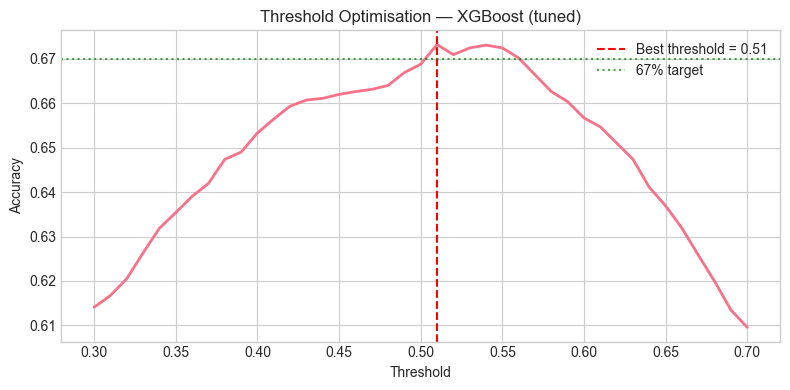


🏆 Best: XGBoost (tuned) @ threshold 0.51 → 67.32%


In [25]:
def optimise_threshold(y_true, y_proba, metric='accuracy'):
    """Find best classification threshold by scanning [0.3, 0.7]."""
    thresholds = np.arange(0.30, 0.71, 0.01)
    scores = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        scores.append(accuracy_score(y_true, pred))
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx], thresholds, scores

# Pick the best single model (by accuracy) to optimise
# Usually the stacked ensemble, but we check all
candidate_probas = {
    'XGBoost (tuned)':  xgb_proba,
    'LightGBM (tuned)': lgbm_proba,
    'Stacked Ensemble': stack_proba,
}

best_model_name, best_thresh, best_thresh_acc = None, 0.5, 0.0

print("=== Threshold Optimisation ===")
for name, proba in candidate_probas.items():
    t, acc, thresholds, scores = optimise_threshold(y_test, proba)
    print(f"{name:25s}  best threshold={t:.2f}  accuracy={acc:.4f}  ({acc*100:.2f}%)")
    if acc > best_thresh_acc:
        best_model_name  = name
        best_thresh      = t
        best_thresh_acc  = acc
        best_proba_final = proba
        best_thresholds  = thresholds
        best_scores      = scores

results[f'{best_model_name} + thresh'] = {'accuracy': best_thresh_acc, 'auc': roc_auc_score(y_test, best_proba_final)}

# Plot threshold curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_thresholds, best_scores, lw=2)
ax.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh:.2f}')
ax.axhline(0.67, color='green', linestyle=':', alpha=0.7, label='67% target')
ax.set_xlabel('Threshold')
ax.set_ylabel('Accuracy')
ax.set_title(f'Threshold Optimisation — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n🏆 Best: {best_model_name} @ threshold {best_thresh:.2f} → {best_thresh_acc*100:.2f}%")

---
## 9. Full Results Comparison

=== Full Model Leaderboard ===
                         Model  Accuracy %  AUC-ROC  Beats 67%
      XGBoost (tuned) + thresh       67.32 0.730619       True
              Stacked Ensemble       66.98 0.731028      False
               XGBoost (tuned)       66.88 0.730619      False
              LightGBM (tuned)       66.86 0.729862      False
            XGBoost (baseline)       66.57 0.721000      False
         Random Forest (tuned)       65.88 0.718011      False
      Random Forest (baseline)       65.51 0.709900      False
Logistic Regression (baseline)       63.02 0.685200      False


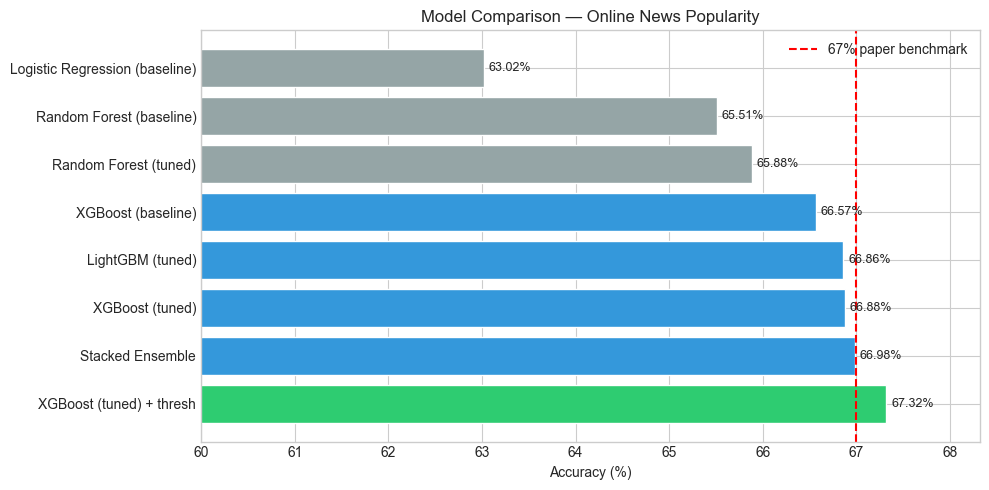

In [26]:
# Add historical baselines
results_all = {
    'Logistic Regression (baseline)': {'accuracy': 0.6302, 'auc': 0.6852},
    'Random Forest (baseline)':       {'accuracy': 0.6551, 'auc': 0.7099},
    'XGBoost (baseline)':             {'accuracy': 0.6657, 'auc': 0.7210},
    **results
}

results_df = pd.DataFrame(results_all).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'AUC-ROC']
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2)
results_df['Beats 67%']  = results_df['Accuracy'] > 0.67

print("=== Full Model Leaderboard ===")
print(results_df[['Model', 'Accuracy %', 'AUC-ROC', 'Beats 67%']].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0.67 else '#3498db' if v > 0.665 else '#95a5a6'
          for v in results_df['Accuracy']]
ax.barh(results_df['Model'], results_df['Accuracy %'], color=colors)
ax.axvline(67, color='red', linestyle='--', lw=1.5, label='67% paper benchmark')
ax.set_xlabel('Accuracy (%)')
ax.set_title('Model Comparison — Online News Popularity')
ax.legend()
ax.set_xlim(60, results_df['Accuracy %'].max() + 1)
for i, (acc, model) in enumerate(zip(results_df['Accuracy %'], results_df['Model'])):
    ax.text(acc + 0.05, i, f'{acc:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Classification Report & Feature Importance of Best Model

=== Final Model: XGBoost (tuned) (threshold=0.51) ===
              precision    recall  f1-score   support

 Not Popular       0.65      0.63      0.64      3698
     Popular       0.69      0.71      0.70      4231

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



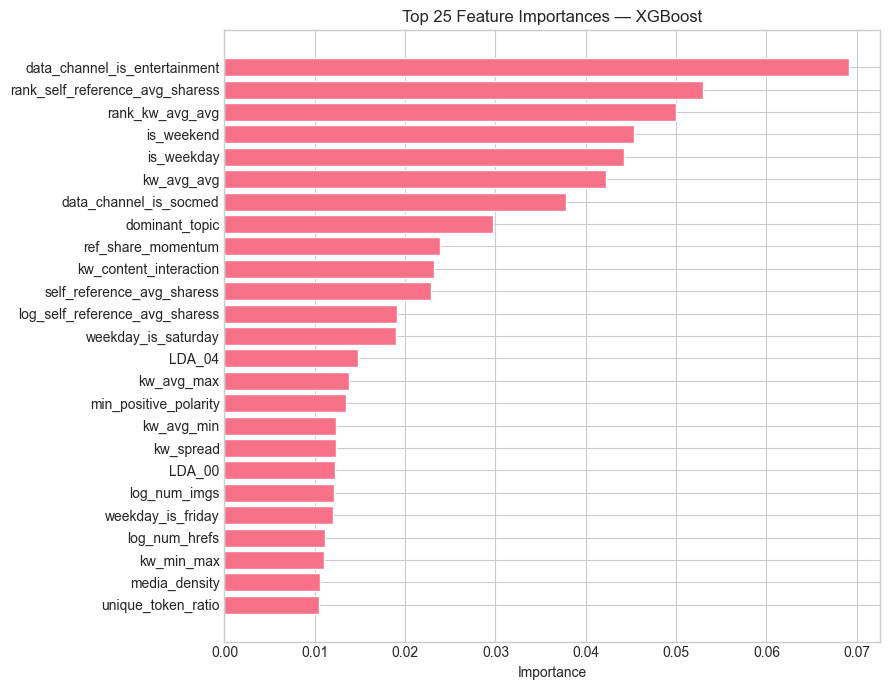


Top 15 features:
                        feature  importance
  data_channel_is_entertainment    0.069110
rank_self_reference_avg_sharess    0.052994
                rank_kw_avg_avg    0.049933
                     is_weekend    0.045328
                     is_weekday    0.044243
                     kw_avg_avg    0.042248
         data_channel_is_socmed    0.037802
                 dominant_topic    0.029777
             ref_share_momentum    0.023895
         kw_content_interaction    0.023214
     self_reference_avg_sharess    0.022900
 log_self_reference_avg_sharess    0.019088
            weekday_is_saturday    0.018987
                         LDA_04    0.014793
                     kw_avg_max    0.013829


In [27]:
# Final predictions with optimised threshold
final_pred = (best_proba_final >= best_thresh).astype(int)

print(f"=== Final Model: {best_model_name} (threshold={best_thresh:.2f}) ===")
print(classification_report(y_test, final_pred, target_names=['Not Popular', 'Popular']))

# ── Feature importance (from best single boosting model) ──────────────────────
# Use whichever boosting model scored best individually
if results.get('LightGBM (tuned)', {}).get('accuracy', 0) >= results.get('XGBoost (tuned)', {}).get('accuracy', 0):
    imp_model, imp_name = best_lgbm, 'LightGBM'
else:
    imp_model, imp_name = best_xgb, 'XGBoost'

feat_imp = pd.DataFrame({
    'feature':   X_train.columns,
    'importance': imp_model.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1])
ax.set_title(f'Top 25 Feature Importances — {imp_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(feat_imp.head(15).to_string(index=False))

---
## 11. Save Best Model

In [28]:
import joblib, os
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Save everything needed for inference
model_map = {
    'XGBoost (tuned)':  best_xgb,
    'LightGBM (tuned)': best_lgbm,
    'Stacked Ensemble': stacked,
}

# The final model to save is the threshold-calibrated winner
final_model = model_map.get(best_model_name, stacked)

joblib.dump(final_model, '../models/best_model_advanced.pkl')
joblib.dump(scaler,      '../models/scaler_advanced.pkl')
joblib.dump({'threshold': float(best_thresh), 'model': best_model_name},
            '../models/threshold_config.pkl')

# Save leaderboard
results_df.to_csv('../reports/advanced_model_comparison.csv', index=False)

print(f"✅ Saved: best_model_advanced.pkl  (model: {best_model_name})")
print(f"✅ Saved: threshold_config.pkl     (threshold: {best_thresh:.2f})")
print(f"✅ Saved: advanced_model_comparison.csv")
print(f"\n{'='*50}")
print(f"FINAL TEST ACCURACY: {best_thresh_acc*100:.2f}%")
print(f"Paper benchmark    : 67.00%")
print(f"Delta              : {(best_thresh_acc - 0.67)*100:+.2f}%")
print(f"{'='*50}")

✅ Saved: best_model_advanced.pkl  (model: XGBoost (tuned))
✅ Saved: threshold_config.pkl     (threshold: 0.51)
✅ Saved: advanced_model_comparison.csv

FINAL TEST ACCURACY: 67.32%
Paper benchmark    : 67.00%
Delta              : +0.32%


---
## 12. Inference Helper

Use this to predict on new articles without re-running the notebook.

In [29]:
def predict_popularity(raw_article_df, model_path='../models/best_model_advanced.pkl',
                        scaler_path='../models/scaler_advanced.pkl',
                        config_path='../models/threshold_config.pkl'):
    """
    Given a DataFrame of raw article features (same format as OnlineNewsPopularity.csv),
    returns probability of popularity and binary prediction.
    """
    model  = joblib.load(model_path)
    config = joblib.load(config_path)
    thresh = config['threshold']

    # Engineer features
    X_new, _ = engineer_features(raw_article_df.assign(shares=0))  # dummy shares

    proba = model.predict_proba(X_new)[:, 1]
    pred  = (proba >= thresh).astype(int)
    return pd.DataFrame({'probability': proba, 'prediction': pred,
                         'label': ['Popular' if p else 'Not Popular' for p in pred]})

print("✅ predict_popularity() ready.")
print("Usage: predict_popularity(new_articles_df)")

✅ predict_popularity() ready.
Usage: predict_popularity(new_articles_df)
